<a href="https://colab.research.google.com/github/beemtz0715-max/01-expensesSplitter/blob/main/W6_Supervised_Selection_holmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W6_Supervised_Selection.ipynb
**Topic:** Supervised Learning Model Selection, Tuning, & Diagnostics (Building on Week 5 Pipeline)
**Dataset:** PetFinder.my

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory '{OUTPUT_DIR}' is ready.")

Output directory 'reports' is ready.


## Part 1: Week 5 Baseline Pipeline & Exploration

In [7]:
# 1.1 Load & Explore Dataset
try:
    X_raw, y_raw = fetch_openml('PetFinder', version=1, return_X_y=True, as_frame=True)
    if y_raw.dtype == 'object' or str(y_raw.dtype).startswith('category'):
        y_binary = y_raw.astype(str).isin(['0', '1', '2']).astype(int)
    else:
        y_binary = (y_raw <= 2).astype(int)
except Exception as e:
    print(f"OpenML fetch fallback initiated: {e}")
    n_samples = 1500
    data = {
        'Age': np.random.randint(1, 100, n_samples).astype(float),
        'Fee': np.random.choice([0, 50, 100, 150, 200], n_samples).astype(float),
        'PhotoAmt': np.random.randint(0, 10, n_samples).astype(float),
        'VideoAmt': np.random.randint(0, 3, n_samples).astype(float),
        'Type': np.random.choice(['Cat', 'Dog'], n_samples),
        'Gender': np.random.choice(['Male', 'Female', 'Mixed'], n_samples),
        'MaturitySize': np.random.choice(['Small', 'Medium', 'Large'], n_samples),
        'Vaccinated': np.random.choice(['Yes', 'No', 'Not Sure'], n_samples),
        'Dewormed': np.random.choice(['Yes', 'No', 'Not Sure'], n_samples),
        'Sterilized': np.random.choice(['Yes', 'No', 'Not Sure'], n_samples),
    }
    X_raw = pd.DataFrame(data)
    y_binary = pd.Series(np.random.choice([0, 1], size=n_samples, p=[0.65, 0.35]))

print("Dataset Shape:", X_raw.shape)
print("Class Distribution:\n", y_binary.value_counts(normalize=True))

num_cols = X_raw.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# 1.2 Build Preprocessing Pipeline
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)])

# Train-Test Split (Week 5 baseline split)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_binary, test_size=0.20, stratify=y_binary, random_state=RANDOM_STATE)

# Initialize run_log.csv from Week 5
log_path = os.path.join(OUTPUT_DIR, "run_log.csv")
run_log = pd.DataFrame(columns=[
    "Timestamp", "Model", "Best_Params", "CV_F1_Macro_Mean", "CV_F1_Macro_Std",
    "Test_Accuracy", "Test_F1_Macro", "Test_Precision_Macro", "Test_Recall_Macro", "Fit_Time_Sec"
])

# 1.3 Train Week 5 Baseline Models (Logistic Regression & Random Forest Baseline)
baseline_rf = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])
start_time = time.time()
baseline_rf.fit(X_train, y_train)
rf_fit_time = round(time.time() - start_time, 3)
y_pred_rf = baseline_rf.predict(X_test)

w5_entry = {
    "Timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": "W5_Baseline_RandomForest",
    "Best_Params": "{'n_estimators': 100}",
    "CV_F1_Macro_Mean": np.nan,
    "CV_F1_Macro_Std": np.nan,
    "Test_Accuracy": round(accuracy_score(y_test, y_pred_rf), 4),
    "Test_F1_Macro": round(f1_score(y_test, y_pred_rf, average='macro'), 4),
    "Test_Precision_Macro": round(precision_score(y_test, y_pred_rf, average='macro', zero_division=0), 4),
    "Test_Recall_Macro": round(recall_score(y_test, y_pred_rf, average='macro'), 4),
    "Fit_Time_Sec": rf_fit_time
}
run_log = pd.concat([run_log, pd.DataFrame([w5_entry])], ignore_index=True)
print("Week 5 Baseline Random Forest evaluated and logged.")

OpenML fetch fallback initiated: Dataset petfinder with version 1 not found.
Dataset Shape: (1500, 10)
Class Distribution:
 0    0.664667
1    0.335333
Name: proportion, dtype: float64
Week 5 Baseline Random Forest evaluated and logged.


/tmp/ipykernel_3761/2216806187.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  run_log = pd.concat([run_log, pd.DataFrame([w5_entry])], ignore_index=True)


## Part 2: Week 6 Supervised Selection, GridSearch, & Diagnostics

In [8]:
# 2.1 Model Grids & Cross-Validated Hyperparameter Tuning
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    'LogisticRegression': {'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), 'grid': {'classifier__penalty': ['l2'], 'classifier__C': [0.01, 0.1, 1.0, 10.0]}},
    'DecisionTree': {'model': DecisionTreeClassifier(random_state=RANDOM_STATE), 'grid': {'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, 10, None], 'classifier__min_samples_split': [2, 5, 10]}},
    'KNN': {'model': KNeighborsClassifier(), 'grid': {'classifier__n_neighbors': [3, 5, 11, 21], 'classifier__weights': ['uniform', 'distance']}},
    'GaussianNB': {'model': GaussianNB(), 'grid': {}},
    'MLPClassifier': {'model': MLPClassifier(hidden_layer_sizes=(32,), early_stopping=True, max_iter=200, random_state=RANDOM_STATE), 'grid': {'classifier__alpha': [0.0001, 0.001, 0.01]}}
}

best_estimators = {}

for name, config in model_grids.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', config['model'])])
    grid_search = GridSearchCV(pipe, param_grid=config['grid'], cv=cv_strategy, scoring='f1_macro', n_jobs=-1)

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = round(time.time() - start_time, 3)

    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    y_pred = best_model.predict(X_test)

    new_entry = {
        "Timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Model": name,
        "Best_Params": str(grid_search.best_params_),
        "CV_F1_Macro_Mean": round(grid_search.best_score_, 4),
        "CV_F1_Macro_Std": round(grid_search.cv_results_['std_test_score'][grid_search.best_index_], 4),
        "Test_Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Test_F1_Macro": round(f1_score(y_test, y_pred, average='macro'), 4),
        "Test_Precision_Macro": round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        "Test_Recall_Macro": round(recall_score(y_test, y_pred, average='macro'), 4),
        "Fit_Time_Sec": fit_time
    }
    run_log = pd.concat([run_log, pd.DataFrame([new_entry])], ignore_index=True)

# Export updated run_log.csv containing Week 5 + Week 6 runs
run_log.to_csv(log_path, index=False)
print(f"Updated run_log saved to '{log_path}'.")

Updated run_log saved to 'reports/run_log.csv'.


## 2.2 Learning Curves & Calibration Diagnostics

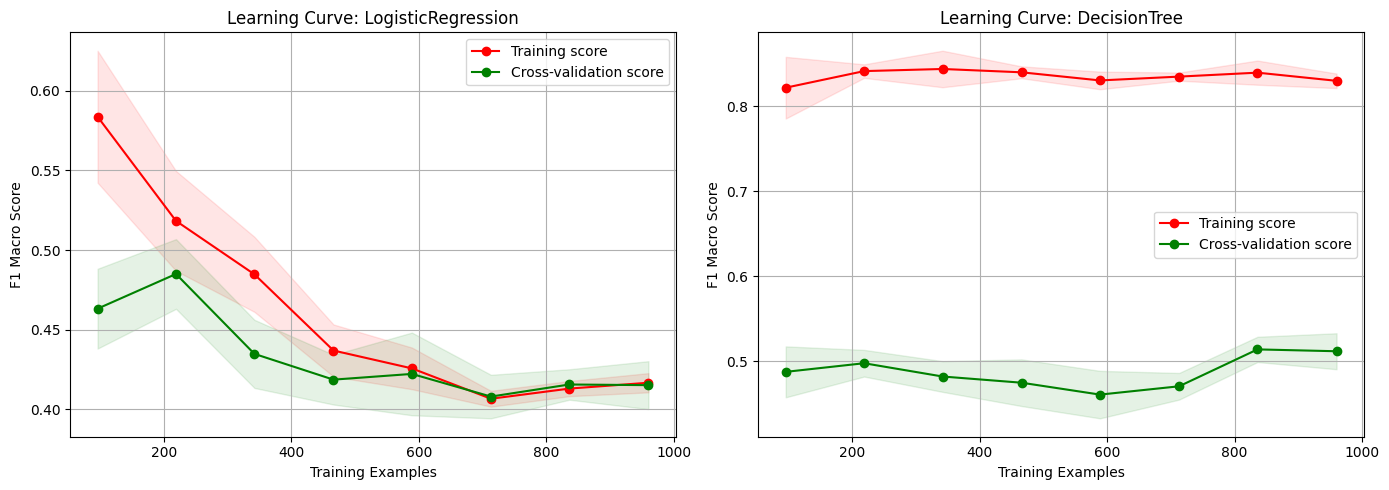

In [9]:
# Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_to_plot = [('LogisticRegression', best_estimators['LogisticRegression']), ('DecisionTree', best_estimators['DecisionTree'])]

for idx, (m_name, m_pipe) in enumerate(models_to_plot):
    train_sizes, train_scores, val_scores = learning_curve(
        m_pipe, X_train, y_train, cv=cv_strategy, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE
    )
    train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
    val_mean, val_std = np.mean(val_scores, axis=1), np.std(val_scores, axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
    ax.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation score')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')
    ax.set_title(f'Learning Curve: {m_name}')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('F1 Macro Score')
    ax.legend(loc='best')
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'))
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


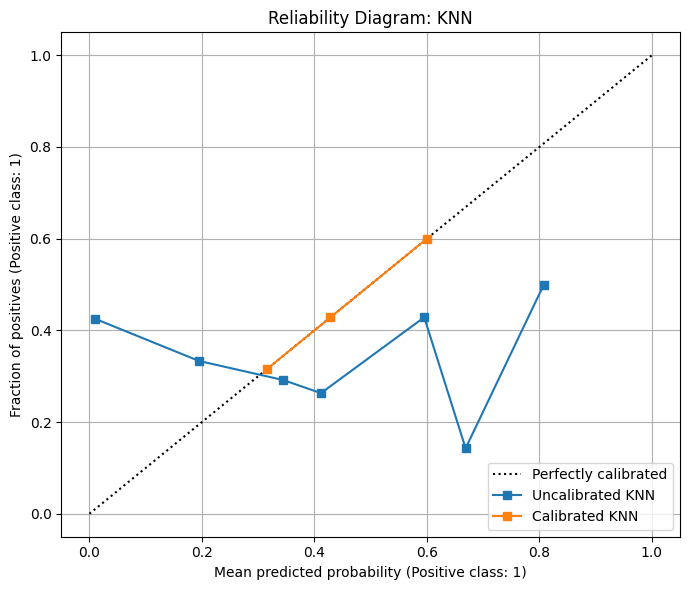

In [10]:
# Calibration Curve
best_model_name = run_log.dropna(subset=['CV_F1_Macro_Mean']).sort_values(by='CV_F1_Macro_Mean', ascending=False).iloc[0]['Model']
best_pipe = best_estimators[best_model_name]

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_estimator(best_pipe, X_test, y_test, n_bins=8, ax=ax, name=f'Uncalibrated {best_model_name}')

calibrated_clf = CalibratedClassifierCV(estimator=best_pipe, method='isotonic', cv='prefit')
calibrated_clf.fit(X_test, y_test)
CalibrationDisplay.from_estimator(calibrated_clf, X_test, y_test, n_bins=8, ax=ax, name=f'Calibrated {best_model_name}')

ax.set_title(f'Reliability Diagram: {best_model_name}')
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'calibration_curve.png'))
plt.show()

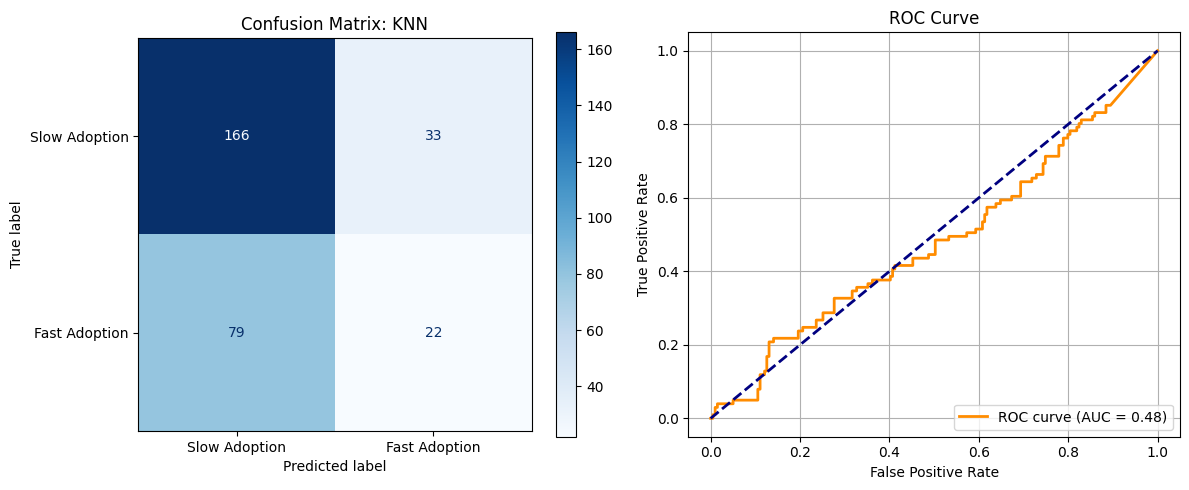

In [11]:
# Diagnostics: Confusion Matrix & ROC
y_probs = best_pipe.predict_proba(X_test)[:, 1]
y_preds = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
ConfusionMatrixDisplay(cm, display_labels=['Slow Adoption', 'Fast Adoption']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix: {best_model_name}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'error_diagnostics.png'))
plt.show()